# Anharmonic phonon renormalisation with dynaphopy — EMT-Cu quick demo

A minimal end-to-end run of `calculate_phonon_md_renormalisation` (v0.0.8)
on FCC Cu with the EMT calculator, gated only on the `[phonons-md]` install
extra and runnable in CI's standard notebook environment.

For a more interesting example using a foundation model (GRACE-1L-OAM) and
a native LAMMPS MD driver side by side, see
[`dynaphopy_grace_example.ipynb`](dynaphopy_grace_example.ipynb).
That one is excluded from CI's `build-notebooks` job because it requires a
custom env with `tensorpotential` + a `pair_style grace`-capable LAMMPS
build.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import matplotlib.pyplot as plt
from ase.build import bulk
from ase.calculators.emt import EMT

## Structure + engine

FCC Cu primitive (1-atom basis, 3 acoustic modes per q-point) and a
standard `ASEEngine` wrapping ASE's EMT calculator.

In [2]:
from pyiron_workflow_atomistics.engine import ASEEngine, CalcInputStatic

cu = bulk("Cu", "fcc", a=3.6)  # 1-atom primitive
engine = ASEEngine(
    EngineInput=CalcInputStatic(),
    calculator=EMT(),
    working_directory="./_dynaphopy_emt_runs",
)
print(f"Structure: {cu.get_chemical_formula()}  ({len(cu)} atoms)")

Structure: Cu  (1 atoms)


## Run the macro

Run the macro with `q_points=None` — it auto-derives a high-symmetry
band path via `ase.dft.kpoints.bandpath`, returning a discretised
dispersion of harmonic and renormalised frequencies. EMT-Cu is
essentially harmonic so this primarily serves as an end-to-end
workflow smoke test the CI can run cheaply.

In [3]:
from pyiron_workflow_atomistics.physics.phonons import (
    calculate_phonon_md_renormalisation,
)

wf = calculate_phonon_md_renormalisation(
    structure=cu,
    engine=engine,
    fc2_supercell_matrix=2 * np.eye(3, dtype=int),
    temperature=300.0,
    equilibration_steps=200,
    production_steps=2000,
    time_step=1.0,
    thermostat_time_constant=100.0,
    q_points=None,                          # ASE-auto high-symmetry band path
    band_npoints=15,                        # coarse path for speed
    seed=42,
    power_spectra=False,
    keep_handles=False,
)
wf.run()
out = wf.outputs.md_phonon_output.value
print(f"converged:        {out.converged}")
print(f"⟨T⟩ measured:     {out.md_temperature_mean:.1f} K  (target {out.temperature:.0f} K)")
print(f"σ_T:              {out.md_temperature_std:.1f} K")
print(f"q_points shape:   {out.q_points.shape}")
print(f"harmonic shape:   {out.harmonic_frequencies.shape}")
print(f"renormalised dispersion (mean over q, per band, THz):")
print(np.nanmean(out.renormalised_frequencies, axis=0))

No velocity provided! calculating it from coordinates...
MD cell size relation: [2 2 2]
Using 2000 steps
Calculating phonon projection power spectra
Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[-1.11725995e-06 -1.10939571e-06 -1.10629009e-06]



Peak # 1
----------------------------------------------
Width                             0.067921 THz
Position                          9.638078 THz
Area (<K>)    (Lorentzian)        0.571717 eV
Area (<K>)    (Total)            10.886734 eV
<|dQ/dt|^2>                       1.143435 eV
Base line                         0.257105 eV * ps
Maximum height                    5.358645 eV * ps
Fitting global error              0.006595
Frequency shift                   9.638079 THz

Peak # 2
----------------------------------------------
Width                             0.067921 THz
Position                          9.638078 THz
Area (<K>)    (Lorentzian)        0.571717 eV
Area (<K>)    (Total)            10.886734 eV
<|dQ/dt|^2>                       1.143435 eV
Base line                         0.257105 eV * ps
Maximum height                    5.358645 eV * ps
Fitting global error              0.006595
Frequency shift                   9.638079 THz

Peak # 3
----------------------------

Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 9.41121719  9.41121719 13.82054306]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 9.41121719  9.41121719 13.82054306]



Peak # 1
----------------------------------------------
Width                             0.084536 THz
Position                         16.166228 THz
Area (<K>)    (Lorentzian)        0.414574 eV
Area (<K>)    (Total)            12.340858 eV
<|dQ/dt|^2>                       0.829147 eV
Base line                         0.297053 eV * ps
Maximum height                    3.122058 eV * ps
Fitting global error              0.013641
Frequency shift                   6.755011 THz

Peak # 2
----------------------------------------------
Width                             0.084536 THz
Position                         16.166228 THz
Area (<K>)    (Lorentzian)        0.414574 eV
Area (<K>)    (Total)            12.340858 eV
<|dQ/dt|^2>                       0.829147 eV
Base line                         0.297053 eV * ps
Maximum height                    3.122058 eV * ps
Fitting global error              0.013641
Frequency shift                   6.755011 THz

Peak # 3
----------------------------

...

Harmonic frequencies (THz):
[ 9.41121719  9.41121719 13.82054306]


Projecting into phonon mode
Projecting into wave vector
Harmonic frequencies (THz):
[ 9.41121719  9.41121719 13.82054306]


Projecting into phonon mode
Projecting into wave vector


Harmonic frequencies (THz):
[ 9.41121719  9.41121719 13.82054306]



Peak # 1
----------------------------------------------
Width                             0.084535 THz
Position                         16.166229 THz
Area (<K>)    (Lorentzian)        0.414574 eV
Area (<K>)    (Total)            12.340862 eV
<|dQ/dt|^2>                       0.829148 eV
Base line                         0.297053 eV * ps
Maximum height                    3.122076 eV * ps
Fitting global error              0.013641
Frequency shift                   6.755011 THz

Peak # 2
----------------------------------------------
Width                             0.084535 THz
Position                         16.166229 THz
Area (<K>)    (Lorentzian)        0.414574 eV
Area (<K>)    (Total)            12.340862 eV
<|dQ/dt|^2>                       0.829148 eV
Base line                         0.297053 eV * ps
Maximum height                    3.122076 eV * ps
Fitting global error              0.013641
Frequency shift                   6.755011 THz

Peak # 3
----------------------------

## Plot — phonon dispersion along the ASE-auto band path

Lines = harmonic dispersion (phonopy at each q-point on the band path).
Markers = MD-projected renormalised frequencies (dynaphopy fit per band).
EMT-Cu is essentially harmonic, so the two should track each other up
to short-MD fit noise.

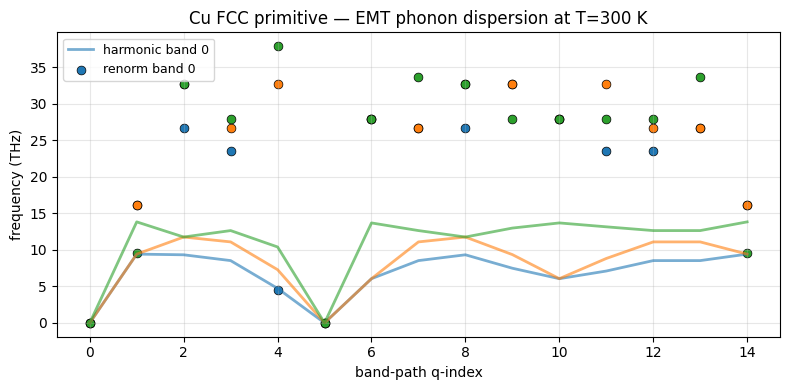

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
q_index = np.arange(out.q_points.shape[0])
for b in range(out.harmonic_frequencies.shape[1]):
    ax.plot(q_index, out.harmonic_frequencies[:, b], color=f"C{b}", lw=2, alpha=0.6,
            label=f"harmonic band {b}" if b == 0 else None)
    ax.scatter(q_index, out.renormalised_frequencies[:, b], color=f"C{b}", marker="o",
               s=40, edgecolor="black", linewidth=0.5,
               label=f"renorm band {b}" if b == 0 else None)
ax.set_xlabel("band-path q-index")
ax.set_ylabel("frequency (THz)")
ax.set_title("Cu FCC primitive — EMT phonon dispersion at T=300 K")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## What else the macro offers

- `q_points=None` (default) → auto-derived high-symmetry band path
  from `ase.dft.kpoints.bandpath`, useful for plotting dispersion.
- `phono3py_output=...` → reuse FC2 from a prior
  `calculate_phonon_thermal_conductivity` run, skipping the
  displacement-force fit entirely.
- `keep_handles=True` → keep the `dynaphopy.Quasiparticle`,
  `Dynamics`, and `phonopy.Phonopy` objects on `MdPhononOutput` for
  deeper inspection.
- `MdPhononOutput.check_md_health()` → flags ⟨T⟩ drift or σ_T anomalies;
  the macro auto-warns at completion if either heuristic trips.